In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('/content/Telco_Customer_Churn_Cleaned.csv')

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [3]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

In [7]:
log_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=5000, random_state=42)

In [8]:
train_accuracy = log_model.score(
    X_train,
    y_train
)

print(
    "Training Accuracy:",
    round(train_accuracy*100,2),
    "%"
)

Training Accuracy: 80.5 %


In [9]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

importance['Abs_Coefficient'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Abs_Coefficient
26,Contract_Two year,-1.354768,1.354768
11,InternetService_Fiber optic,1.221273,1.221273
25,Contract_One year,-0.743219,0.743219
22,StreamingTV_Yes,0.414023,0.414023
10,MultipleLines_Yes,0.386622,0.386622
24,StreamingMovies_Yes,0.386146,0.386146
28,PaymentMethod_Electronic check,0.383712,0.383712
14,OnlineSecurity_Yes,-0.352543,0.352543
9,MultipleLines_No phone service,0.345267,0.345267
20,TechSupport_Yes,-0.312608,0.312608


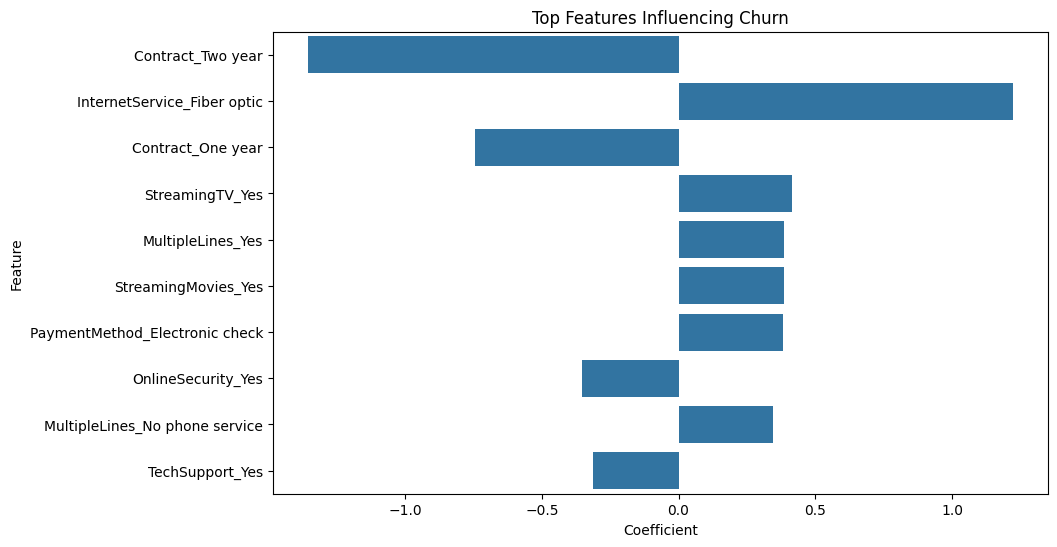

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Coefficient',
    y='Feature'
)

plt.title(
    'Top Features Influencing Churn'
)

plt.show()